# 심화 세션 5차 - 언어 모델 사전과제

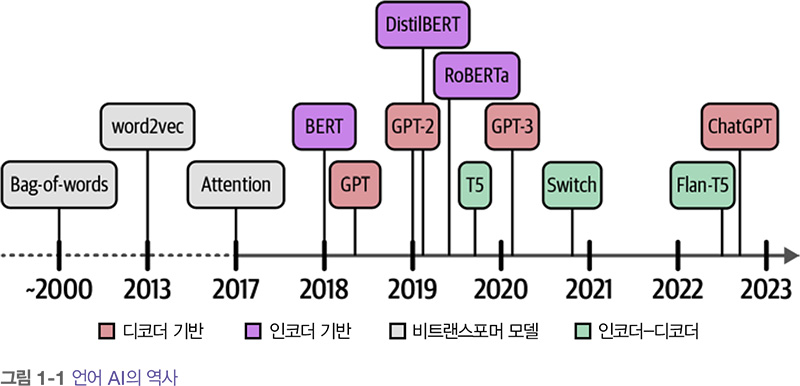

## 1. NLP (자연어 처리)

**NLP(Natural Language Processing)** 는 컴퓨터가 인간의 언어를 이해하고 생성할 수 있도록 하는 AI의 한 분야임.

주요 태스크:
- **텍스트 분류** (감성 분석, 스팸 탐지)
- **기계 번역** (영어 → 한국어 등)
- **질의응답**
- **텍스트 생성**
- **개체명 인식**

NLP 모델의 발전 방향은 크게 **통계 기반 모델 → 신경망 기반 모델 → 트랜스포머 기반 대형 언어 모델** 순으로 이어집니다.

## 2. 통계 기반 모델

딥러닝 이전의 언어 모델은 **확률과 통계**를 기반으로 동작했음.
"다음에 어떤 단어가 올 확률이 높은가?"를 학습 데이터의 빈도로 추정하는 방식!

### 2-1. SLM (Statistical Language Model)

**SLM(통계적 언어 모델)** 은 단어 시퀀스에 확률을 부여하는 모델

문장 $W = w_1, w_2, ..., w_n$ 이 있을 때, 이 문장의 확률을 이렇게 계산한당:

$$P(W) = P(w_1) \cdot P(w_2|w_1) \cdot P(w_3|w_1,w_2) \cdots P(w_n|w_1,...,w_{n-1})$$

이를 **연쇄 법칙** 이라고 함.
그런데 앞의 모든 단어를 다 고려하면 경우의 수가 너무 많아져서 현실적으로 불가능.
이를 해결하기 위해 **N-gram** 방식을 사용!

---

#### 📌 SLM에서 사용되는 분포 가설 (Distributional Hypothesis)

> *"비슷한 문맥에서 등장하는 단어는 비슷한 의미를 가진다."*  

**분포 가설** 은 NLP 전반에 걸쳐 핵심적인 아이디어입니다.

예를 들어, "강아지"와 "고양이"는 유사한 문맥("귀엽다", "키운다", "먹이를 준다")에서 자주 등장하기 때문에 의미적으로 유사하다고 볼 수 있을 듯.

SLM은 이 가설을 토대로, 단어의 공기 빈도를 이용해 언어의 패턴을 학습함.
후에 등장하는 Word2Vec, GloVe 등의 단어 임베딩도 이 가설에 기반함.

### 2-2. N-gram

**N-gram** 은 연속된 N개의 단어를 하나의 단위로 보는 모델  
SLM의 계산 복잡도 문제를 해결하기 위해 **마르코프 가정** 을 사용

> 마르코프 가정: 다음 단어는 **바로 앞 N-1개의 단어**에만 의존

| 종류 | 조건부 확률 | 예시 |
|------|------------|------|
| Unigram (1-gram) | $P(w_i)$ | 각 단어가 독립적으로 등장 |
| Bigram (2-gram) | $P(w_i \| w_{i-1})$ | "나는" 다음에 "밥을"이 올 확률 |
| Trigram (3-gram) | $P(w_i \| w_{i-2}, w_{i-1})$ | 앞 두 단어를 조건으로 |

**확률 계산:**
```
P("오늘 날씨 좋다") ≈ P(날씨|오늘) × P(좋다|날씨)
```

---

#### 📌 N-gram이 나온 배경과 한계

**배경:**
- 전체 문맥을 고려하는 완전한 언어 모델은 데이터 희소성 문제가 심각함
- 학습 데이터에서 본 적 없는 단어 조합의 확률을 0으로 추정하는 문제 발생
- 현실적인 근사로서 "최근 N개의 단어만 보자"는 N-gram 제안됨

**한계:**
1. **데이터 희소 문제:** N이 커질수록 학습 데이터에서 해당 N-gram을 본 적이 없는 경우가 많아짐
2. **장거리 의존성 포착 불가:** 문장의 앞부분과 뒷부분의 관계를 학습할 수 없음  
   예) "나는 어제 친구를 만났고, 우리는 같이 **밥을** 먹었다" → 앞의 맥락을 살리기 어려움
3. **저장 공간 문제:** N이 커질수록 저장해야 할 N-gram의 수가 기하급수적으로 증가

### 2-3. PPL (퍼플렉시티)

**PPL** 은 언어 모델이 얼마나 "당황스러워하는지"를 나타내는 평가 지표  
쉽게 말해, 모델이 테스트 문장을 얼마나 잘 예측하는지를 수치로 나타낸 것

$$PPL(W) = P(w_1, w_2, ..., w_N)^{-\frac{1}{N}}$$

- **PPL이 낮을수록** 모델이 문장을 잘 예측한다 = 좋은 모델
- **PPL이 높을수록** 모델이 다음 단어를 맞추기 어렵다 = 나쁜 모델

**적용해 보자면?**  
> PPL = 10 이라면? 모델이 매 단어를 예측할 때 평균적으로 10개 중 1개를 고르는 것과 같음

PPL은 같은 테스트셋에서 비교해야 의미가 있고, 도메인이 다른 모델 간 비교에는 적합하지 않겠지

### 2-4. NLM

**NLM** 은 통계 기반 N-gram의 한계를 극복하기 위해 등장한 모델
대표적으로 **Bengio et al. (2003)** 의 NNLM이 있음

NLM의 핵심 아이디어
- 단어를 **밀집 벡터** 로 표현
- 신경망으로 단어 간 의미적 유사성을 학습
- 학습 데이터에서 본 적 없는 단어 조합도 유사 문맥을 통해 확률 추정 가능

---

#### 📌 SLM과의 차이

| 비교 항목 | SLM (통계적 언어 모델) | NLM (신경망 언어 모델) |
|----------|----------------------|----------------------|
| 단어 표현 | One-hot (희소 벡터) | Dense Embedding (밀집 벡터) |
| 확률 추정 | 빈도 기반 카운팅 | 신경망 학습 |
| 희소성 문제 | 심각 (본 적 없으면 확률 0) | 완화 (유사 단어로 일반화) |
| 장거리 의존성 | N 크기로 제한됨 | RNN 등으로 어느 정도 포착 가능 |
| 계산 비용 | 낮음 | 높음 |

NLM은 SLM의 희소성 문제를 해결했지만, RNN/LSTM 기반 초기 NLM은 여전히 **장거리 의존성 학습의 어려움**과 **병렬 처리 불가** 문제가 있었음.
이를 근본적으로 해결한 것이 **Transformer** 구조

## 3. 딥러닝 기반 모델

2017년 "Attention is All You Need" 논문에서 **Transformer** 구조가 제안된 이후, NLP 모델의 패러다임이 완전히 바뀌게 됨.
Transformer의 **Self-Attention 메커니즘**은 문장 내 모든 단어 간의 관계를 동시에 포착할 수 있어, 장거리 의존성 문제를 해결한 것!

### 3-1. BERT

**BERT** 는 2018년 Google이 발표한 모델

**요약하자면**
- Transformer의 **인코더(Encoder)** 부분만 사용
- **양방향(Bidirectional)** 학습: 문장의 앞뒤 문맥을 모두 고려
- 두 가지 사전학습 태스크:
  1. **MLM:** 문장의 일부 단어를 [MASK]로 가리고 맞추기
  2. **NSP:** 두 문장이 이어지는 문장인지 예측

**특징:**
- 사전학습 후 **Fine-tuning** 방식으로 다양한 다운스트림 태스크에 활용
- 텍스트 분류, NER, 질의응답 등에서 뛰어난 성능
- 텍스트 이해에 강점 --> 생성보다는 분류/추출 태스크에 적합

### 3-2. GPT

**GPT** 는 OpenAI가 발표한 모델이고 BERT와 반대로 Transformer의 **디코더** 부분을 사용!

**요약하자면**
- **단방향 ** 학습: 앞의 단어만 보고 다음 단어 예측
- 대규모 텍스트 데이터로 사전학습 → **텍스트 생성**에 강점
- GPT-1 → GPT-2 → GPT-3 → GPT-4로 이어지는 스케일업

**BERT와의 비교**

| | BERT | GPT |
|--|------|-----|
| 구조 | Transformer Encoder | Transformer Decoder |
| 방향성 | 양방향 | 단방향 (left-to-right) |
| 강점 | 텍스트 이해, 분류 | 텍스트 생성 |
| 학습 방식 | MLM + NSP | 다음 단어 예측 |

### 3-3. LLM

**LLM** 은 수십억~수조 개의 파라미터를 가진 초대규모 언어 모델

**특징:**
- **Few-shot / Zero-shot Learning:** 별도의 Fine-tuning 없이도 프롬프트만으로 다양한 태스크 수행
- **창발적 능력:** 모델 규모가 커지면서 이전에 없던 능력이 갑작스럽게 나타나는 현상
- **지시 따르기:** RLHF(인간 피드백 강화학습) 등으로 사람의 지시를 잘 따르도록 훈련

**대표 모델:** GPT-4, Claude, Gemini, LLaMA, Mistral 등

### 3-4. RAG

**RAG** 는 LLM의 한계를 보완하기 위한 기법

**LLM의 한계**
- 학습 데이터 이후의 최신 정보를 모름
- 사실과 다른 내용을 그럴듯하게 생성하는 **할루시네이션** 문제
- 특정 도메인의 전문 지식 부족

**RAG는?**  
> "답을 생성하기 전에, 관련 문서를 먼저 검색해서 참고하자!"

---

#### 📌 RAG의 구조


```
[사용자 질문]
      │
      ▼
┌─────────────┐
│  Retriever  │  ← 질문과 관련된 문서를 벡터 DB에서 검색
└─────────────┘
      │  관련 문서(Context)
      ▼
┌─────────────┐
│  Generator  │  ← LLM이 질문 + 검색된 문서를 바탕으로 답변 생성
└─────────────┘
      │
      ▼
   [최종 답변]
```

**세부 과정**
1. **문서 인덱싱:** 외부 문서를 청크로 나누고 임베딩 벡터로 변환하여 Vector DB에 저장
2. **검색:** 사용자 질문을 임베딩하고 Vector DB에서 유사한 문서 청크 검색
3. **생성:** 검색된 문서를 컨텍스트로 포함하여 LLM에게 답변 생성 요청

**장점**
- 최신 정보 반영 가능
- 환각 감소 (근거 문서 기반 답변)
- 모델 재학습 없이 지식 업데이트 가능

### 3-5. LangChain

**LangChain** 은 LLM 기반 애플리케이션을 쉽게 개발할 수 있도록 도와주는 프레임워크

---

#### 📌 LangChain의 아이디어와 특징

> "LLM을 단독으로 쓰는 게 아니라, 여러 컴포넌트를 **체인(Chain)** 으로 연결해 복잡한 작업을 수행하자"

마치 레고 블록처럼 여러 기능을 조립해서 LLM 파이프라인을 구성하는 것

**주요 구성 요소**

| 컴포넌트 | 설명 |
|---------|------|
| **LLMs / ChatModels** | GPT, Claude 등 다양한 LLM을 통일된 인터페이스로 사용 |
| **Prompt Templates** | 재사용 가능한 프롬프트 관리 |
| **Chains** | 여러 컴포넌트를 순서대로 연결 |
| **Memory** | 대화 히스토리를 저장하여 멀티턴 대화 지원 |
| **Agents** | LLM이 스스로 도구(Tool)를 선택하고 사용하는 구조 |
| **Vector Stores** | 문서 임베딩 저장 및 검색 (RAG 구현에 활용) |
| **Document Loaders** | PDF, 웹페이지, 데이터베이스 등 다양한 소스에서 문서 로드 |

**특징:**
- 다양한 LLM 제공자(OpenAI, Anthropic, HuggingFace 등)를 교체 가능한 구조
- RAG 파이프라인 구축을 몇 줄의 코드로 구현 가능
- **LCEL(LangChain Expression Language)** 로 체인을 선언적으로 작성 가능

**간단한 LangChain 예시를 보자면 (이거는 지피티한테 예시 달라고 해서 받음 ㅎㅎ..)**
```python
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4o")

prompt = ChatPromptTemplate.from_template(
    "{topic}에 대해 한 문단으로 설명해줘."
)

# LCEL로 체인 구성 (프롬프트 → LLM)
chain = prompt | llm

response = chain.invoke({"topic": "트랜스포머 모델"})
print(response.content)
```

## 4. sLM (small Language Model)

**sLM** 은 LLM의 대안으로 주목받고 있는 작은 규모의 언어 모델 (앞에 S 있으니까)  
일반적으로 파라미터 수가 1B~10B 수준의 모델을 sLM이라고 부름
대표 모델: Phi-3, 젬마, 메타 등

### 4-1. 모델 압축

LLM을 sLM 수준으로 줄이거나, 효율적으로 만들기 위한 기법

**어케 함?**

| 기법 | 설명 |
|------|------|
| **지식 증류** | 큰 모델의 출력을 작은 모델이 학습하도록 하는 방법. 단순히 정답 레이블만 학습하는 것보다 큰 모델의 "소프트 출력(확률 분포)"을 학습하는 것이 효과적 |
| **양자화** | 모델의 가중치를 32-bit float에서 8-bit, 4-bit 정수로 줄여 메모리와 연산량 감소 |
| **가지치기** | 중요도가 낮은 가중치(뉴런, 헤드)를 제거하여 모델을 경량화 |
| **LoRA / Adapter** | 전체 파라미터를 학습하지 않고, 소수의 추가 파라미터만 학습하는 PEFT 기법 |

### 4-2. sLM의 장단점

**장점**
- 경량성: 스마트폰 등에서도 실행 가능할 정도로 가벼움
- 빠른 속도: 파라미터 수가 적어 응답 생성이 따름
- 저비용: 학습 및 서빙 비용이 LLM 대비 낮음
- 온프레이스 배포 기능: 인터넷 연결 없이도 운용 가능 --> 보안과 프라이버시에 유리함
- 특정 도메인 파인튜닝 용이: 도메인 특화 데이터로 파인튜닝하기 쉬움

**단점**
- 낮은 성능: LLM보다 당연히 성능이 낮음
- 제한된 이해: 긴 문서 같은 건 처리 능력이 부족
- 지식 용량 한계: 저장할 수 있는 지식 양이 적음

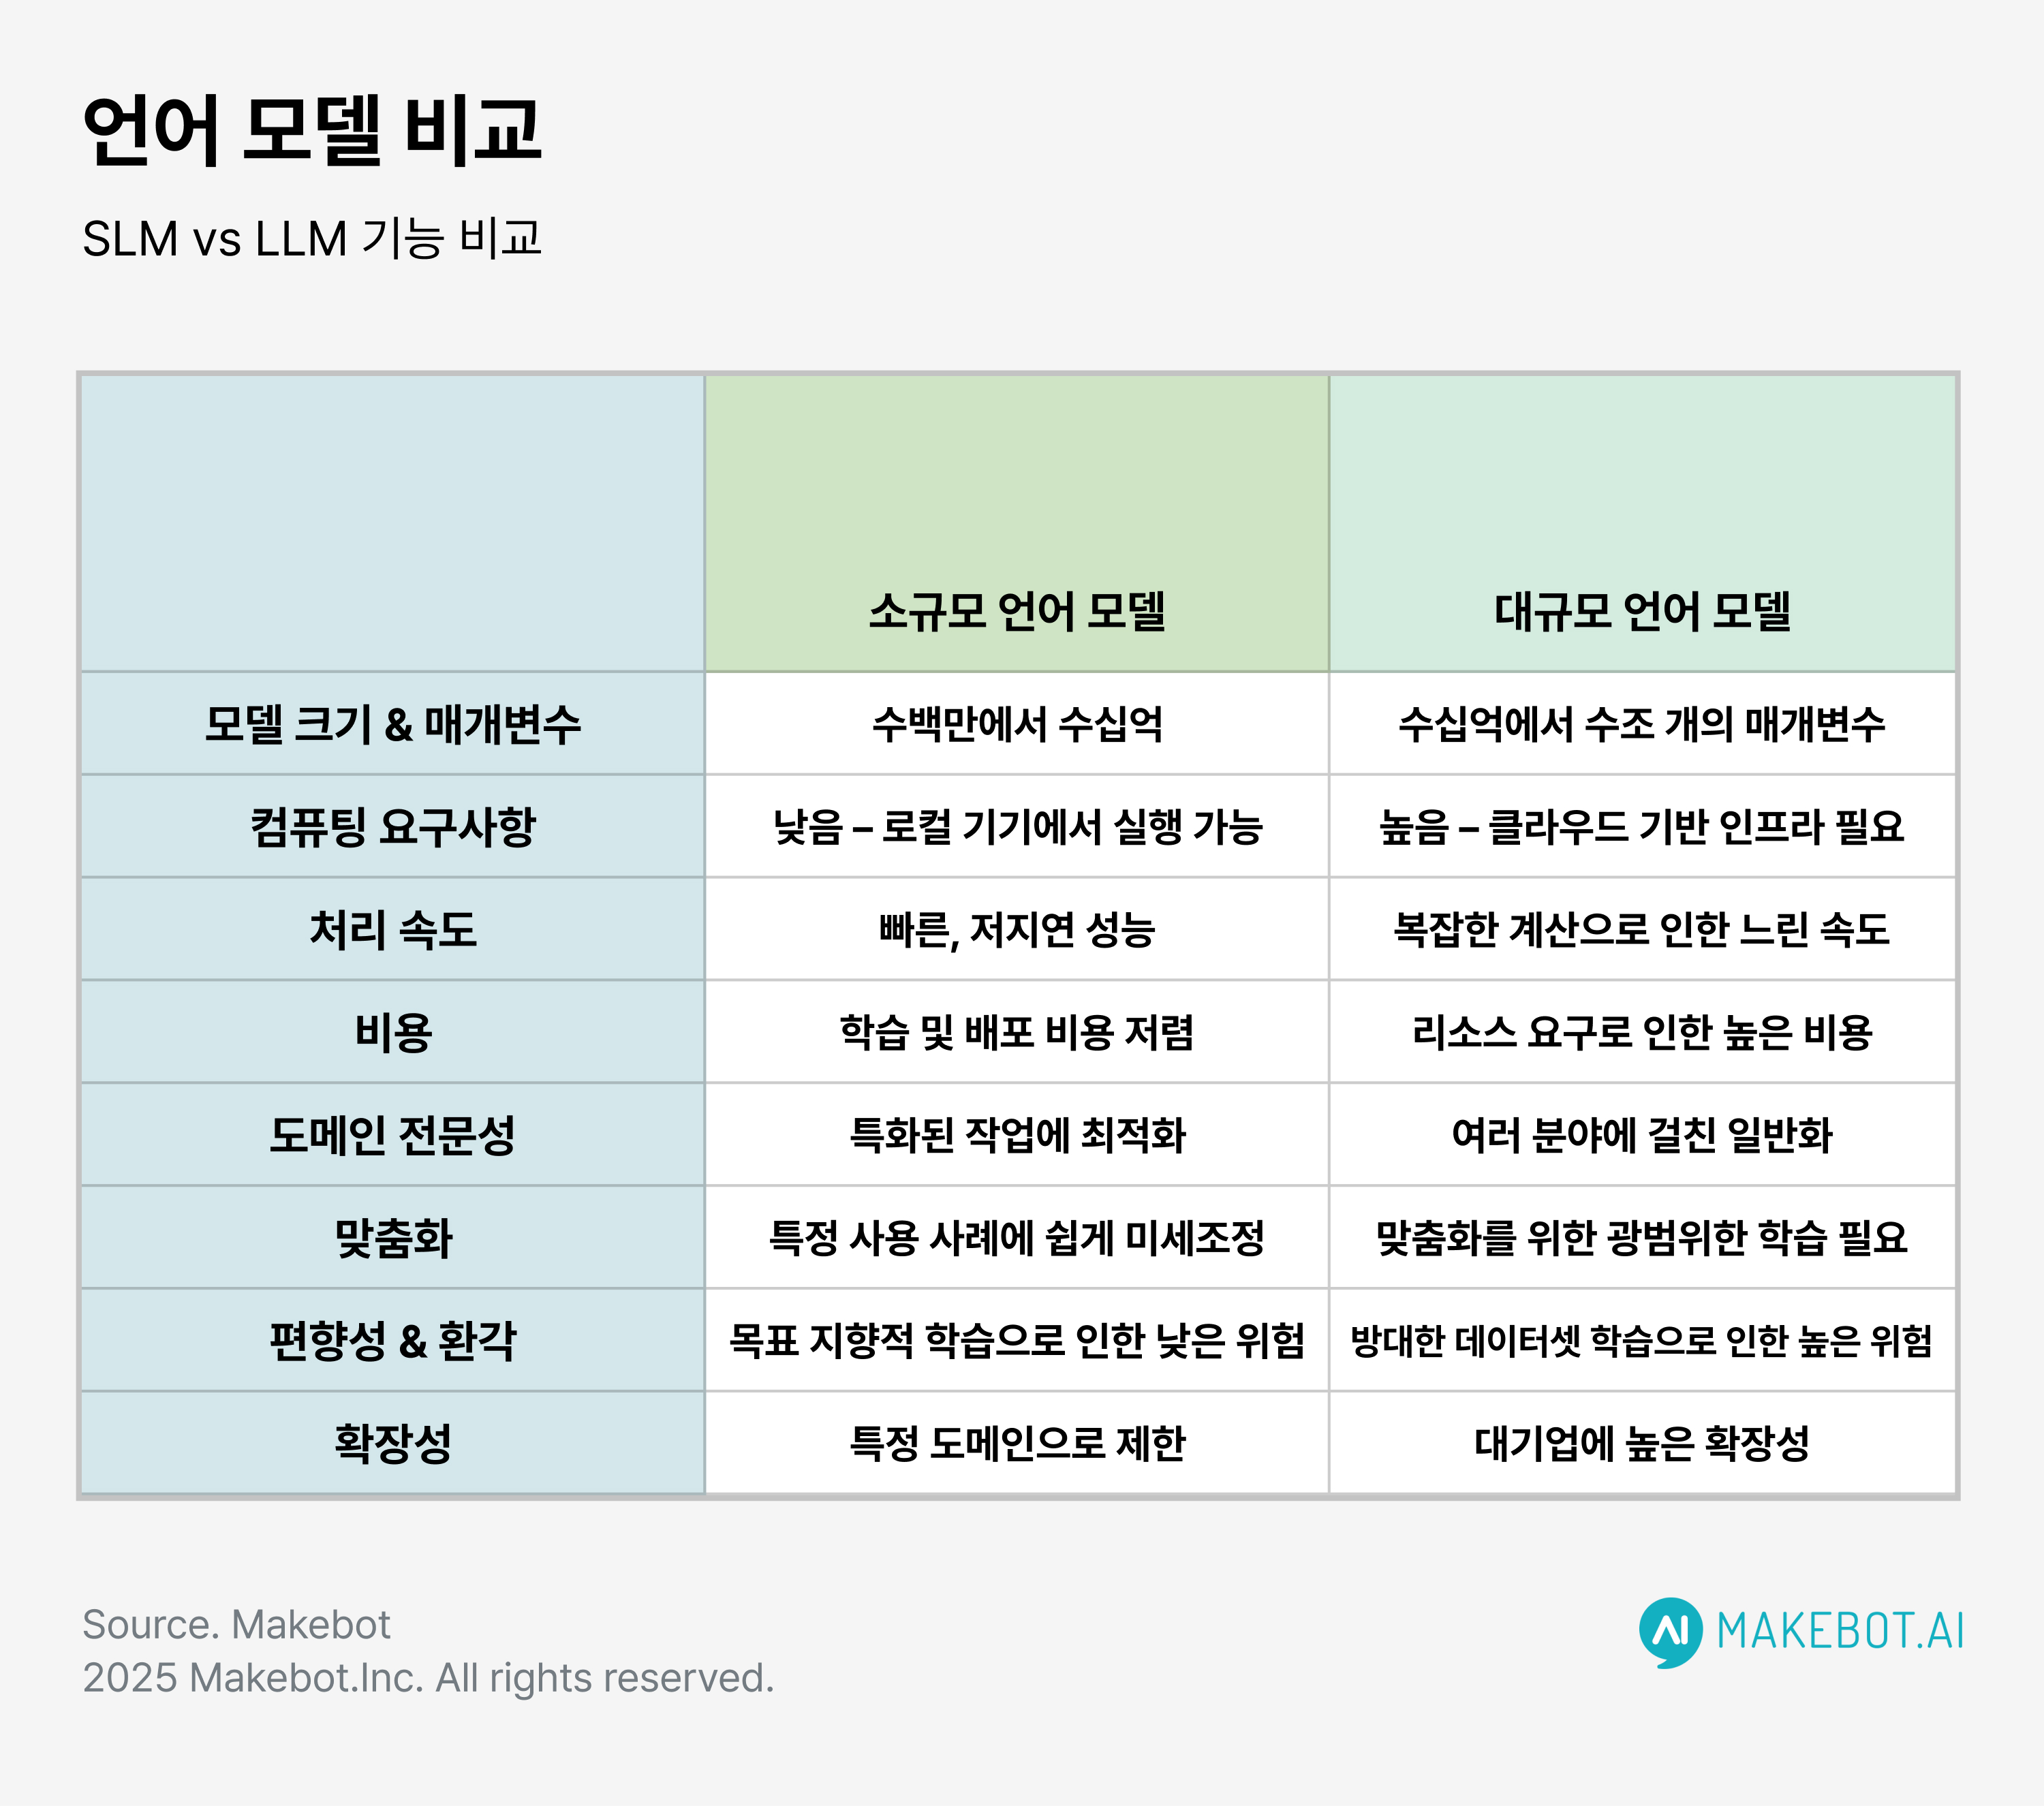

### 4-3. sLM과 LLM의 결합

sLM과 LLM 각각의 장단점을 활용하여 **보완적으로 결합**하는 것이 베스트일 것임

**결합 방식**

**1. 스펙큘레이티브 디코딩**
- sLM이 먼저 빠르게 토큰을 여러 개 예측
- LLM이 예측 결과를 한 번에 검증 및 수정
- LLM 단독 추론 대비 2~3배 빠른 속도 달성 가능

**2. 라우팅**
- 쉬운 질문은 sLM이 처리, 어려운 질문은 LLM으로 라우팅
- 비용과 성능의 균형을 효율적으로 맞출 수 있음

**3. sLM을 에이전트의 서브모듈로 활용**
- LLM이 전체 작업을 계획하고 관리
- 반복적이고 단순한 서브태스크는 sLM에게 위임

**4. Fine-tuned sLM**
- LLM이 생성한 고품질 데이터로 sLM을 파인튜닝
- 특정 도메인에서 LLM에 근접한 성능을 sLM으로 달성

> 즉 sLM과 LLM은 경쟁 관계가 아니라 **상호 보완적인 관계**로 활용될 수 있다

## 요약!!!!!!!!!!!!!!!

```
통계 기반 언어 모델
  ├── SLM (분포 가설 기반)
  ├── N-gram (마르코프 가정으로 근사, 희소성/장거리 의존성 한계)
  └── PPL (언어 모델 평가 지표)

신경망 언어 모델 (NLM)
  └── 단어 임베딩으로 희소성 문제 완화, RNN 기반

딥러닝 기반 (Transformer 이후)
  ├── BERT - Encoder, 양방향, 이해 태스크에 강점
  ├── GPT  - Decoder, 단방향, 생성 태스크에 강점
  └── LLM  - 초대규모 모델, Few-shot, 창발 능력
              ├── RAG (외부 검색 + LLM 생성으로 한계 보완)
              └── LangChain (LLM 앱 개발 프레임워크)

sLM (소형 언어 모델)
  ├── 모델 압축 (증류, 양자화, 가지치기)
  ├── 장단점 (경량·저비용 vs 성능 한계)
  └── LLM과의 결합 (스펙큘레이티브 디코딩, 라우팅 등)
```

# 감사합니다 ~~ 🦭🦭